# RNN IMDB Sentiment Classification

We build a binary sentiment classifier (positive/negative movie review) using an `Embedding` layer followed by a `SimpleRNN`, trained on `tf.keras.datasets.imdb` (top 10k words). This is the vanilla-RNN baseline discussed in `notes.md`, motivating LSTM/GRU in the next topic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

print('TF version:', tf.__version__)

I0000 00:00:1787472226.986412   26428 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472226.986817   26428 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787472227.026758   26428 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787472227.874298   26428 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472227.874612   26428 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF version: 2.21.0


## Load IMDB reviews

We restrict to the 10,000 most frequent words; each review is already encoded as a sequence of integer word indices by Keras.

In [2]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print('Train reviews:', len(X_train_full), 'Test reviews:', len(X_test))
print('Sample review length (tokens):', len(X_train_full[0]))
print('Sample label:', y_train_full[0])

       0/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/17464789 ━━━━━━━━━━━━━━━━━━━━ 2:13 8us/step

   32768/17464789 ━━━━━━━━━━━━━━━━━━━━ 1:44 6us/step

   49152/17464789 ━━━━━━━━━━━━━━━━━━━━ 3:06 11us/step

   81920/17464789 ━━━━━━━━━━━━━━━━━━━━ 2:05 7us/step 

...

17358848/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

17424384/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step


/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/keras/src/datasets/npz_utils.py:68: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return RestrictedUnpickler(fp).load()


Train reviews: 25000 Test reviews: 25000
Sample review length (tokens): 218
Sample label: 1


## Pad sequences

`SimpleRNN` needs fixed-length batches, so we pad/truncate every review to `MAX_LEN` tokens (padding at the front with 0, truncating longest reviews).

In [3]:
X_train_full = pad_sequences(X_train_full, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

val_split = 5000
X_train, X_val = X_train_full[:-val_split], X_train_full[-val_split:]
y_train, y_val = y_train_full[:-val_split], y_train_full[-val_split:]

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (20000, 200) Val: (5000, 200) Test: (25000, 200)


## Build Embedding + SimpleRNN model

In [4]:
model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1787472246.015390   26428 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787472246.015605   26541 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787472246.036444   26428 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8, batch_size=128,
    callbacks=[early_stop], verbose=2)

Epoch 1/8


157/157 - 4s - 25ms/step - accuracy: 0.7496 - loss: 0.4955 - val_accuracy: 0.8374 - val_loss: 0.3745


Epoch 2/8


157/157 - 3s - 19ms/step - accuracy: 0.8715 - loss: 0.3143 - val_accuracy: 0.8400 - val_loss: 0.3713


Epoch 3/8


157/157 - 3s - 19ms/step - accuracy: 0.9114 - loss: 0.2280 - val_accuracy: 0.8576 - val_loss: 0.3772


Epoch 4/8


157/157 - 3s - 20ms/step - accuracy: 0.9246 - loss: 0.2011 - val_accuracy: 0.7764 - val_loss: 0.4797


Epoch 5/8


157/157 - 4s - 23ms/step - accuracy: 0.9453 - loss: 0.1557 - val_accuracy: 0.8344 - val_loss: 0.4440


## Training curves

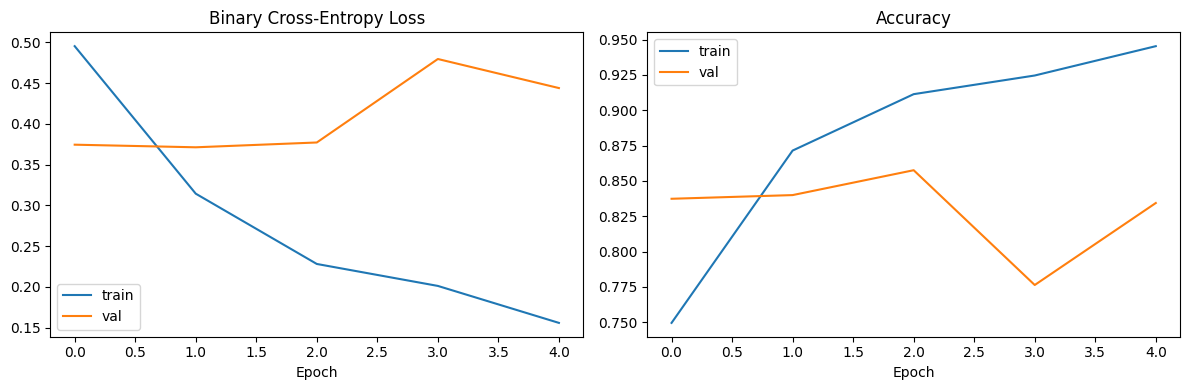

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Binary Cross-Entropy Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout()
plt.show()

## Evaluate on the test set

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss:     {test_loss:.4f}')

Test accuracy: 0.8404
Test loss:     0.3695


## Summary

A single `SimpleRNN` layer on top of learned word embeddings gets meaningfully above chance accuracy on IMDB sentiment, but vanilla RNNs are known to struggle with longer-range dependencies in text (see `notes.md`) — the next topic (`04-lstm-gru`) revisits this same task family with gated recurrent architectures designed to fix that.